In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token="CSi2Ehxcz85ht-yaALKXJWbj7d3lVUzFL_pjM1gv1ED4",
    overwrite=True,
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/e617c893413e4afd9e6f43fcb9bf34a4:bdc75f0b-72b1-40f8-9d75-d03d901f4f5a::",
)


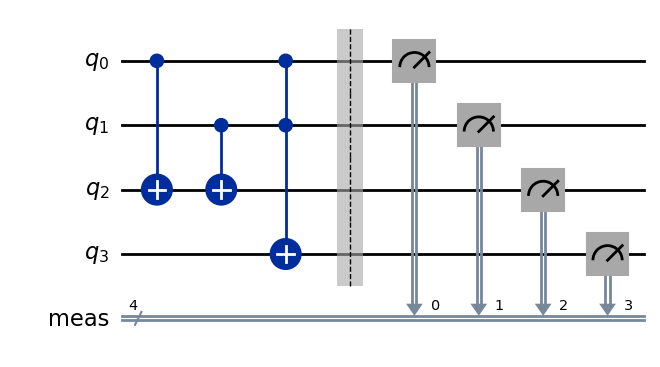

In [3]:
# 큐비트 : a, b, 합 (sum), 자리올림(carry)
from qiskit import QuantumCircuit

qc = QuantumCircuit(4)

# A와 B에 넣을 값을 선택
a = 0
b = 0

# 선택 값에 따라 A, B 큐비트 준비
if a:
    qc.x(0)
if b:
    qc.x(1)

# XOR(합)을 큐비트 2 에 계산
qc.cx(0, 2)
qc.cx(1, 2)

# AND(자리 올림)을 큐비트 3에 계산
qc.ccx(0, 1, 3)

# 측정
qc.measure_all()

qc.draw("mpl")

In [4]:
# IBM Backend 통신 확인

service = QiskitRuntimeService()

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=127
)

print(backend.name)

ibm_fez


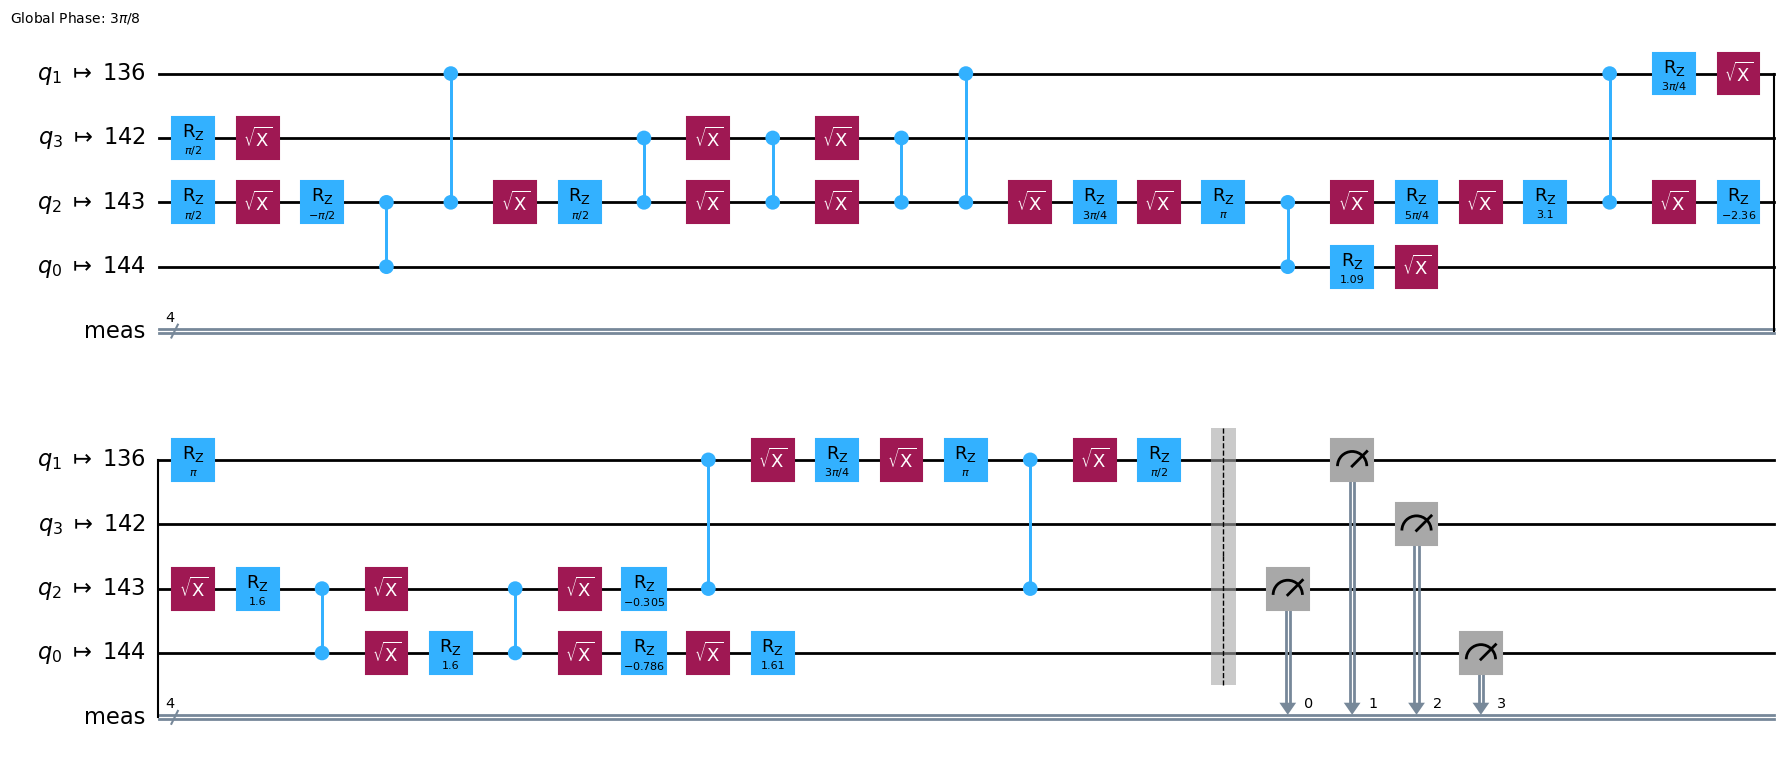

In [5]:
# 선택한 양자 컴퓨터에서 실행 되도록 회로를 트랜스파일하고 최적화합니다.
# 2단계 : 트랜스파일

from qiskit import generate_preset_pass_manager


target = backend.target

pm = generate_preset_pass_manager(target=target, optimization_level=3) # 최적화 수준 (0 : 낮은 최적화, 3: 강한 최적화 )
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

# 트랜스 파일 결과로 나온 회로는 처음 매핑 단계에서 만든 논리회로와는 상당히 다른 모습일 수 있다.
# 실제 양자 하드웨어의 큐비트 연결 구조, 지원 게이트, 오류율 등을 고려해서 회로가 다시 배치되고 변환되기 때문

In [6]:
# Sampler
# 양자 회로를 실행했을 때 나올 수 있는 상태들을 표본으로 추출하고, 각 상태가 어떤 확률로 측정되는지 통계를 모아주는 qiskit의 primitive.
# 즉, 회로를 여러 번 실행해서 측정 결과의 분포를 확인할 때 사용한다.

from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
print(backend.name)
# sampler 라이브러리 필요

ibm_fez


In [7]:
# 실제 양자 컴퓨터 인스턴스를 이용할 수 없을 경우 시뮬레이터를 사용 가능

from qiskit.primitives import BackendSamplerV2

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel


noise_model = NoiseModel.from_backend(backend)

backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

# 또는 일반적인 특성을 가진 가짜 백엔드를 불러와 시뮬레이터 정의 가능
# backend_gen = GenericBackendV2(num_qubits=18)
# sampler_gen = BackendSamplerV2(backend=backend_gen)

In [8]:
print(backend.name)

job = sampler.run([qc_isa], shots=100)
# job = sampler_sim.run([qc_isa])

res = job.result()
counts = res[0].data.meas.get_counts()

ibm_fez


counts =  {'0000': 96, '0010': 2, '0100': 2}


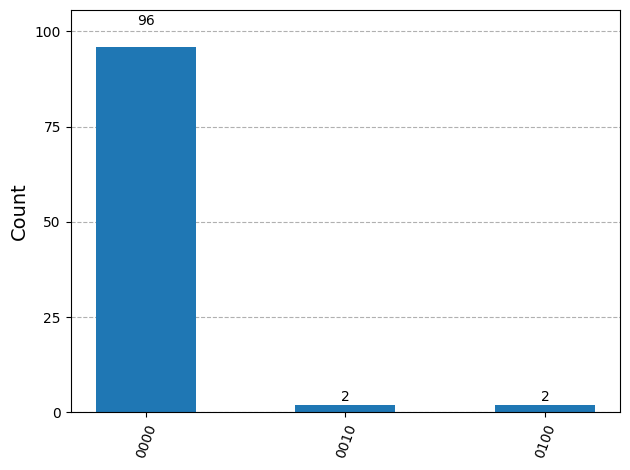

In [9]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)

plot_histogram(counts)